Features for clustering: (299, 11)
Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

=== K-Means Clustering ===


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

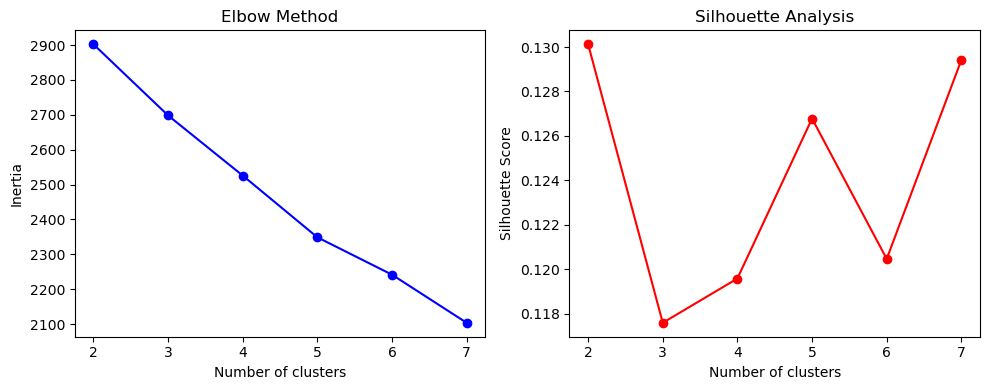

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K-Means Silhouette Score: 0.1176

=== Hierarchical Clustering ===


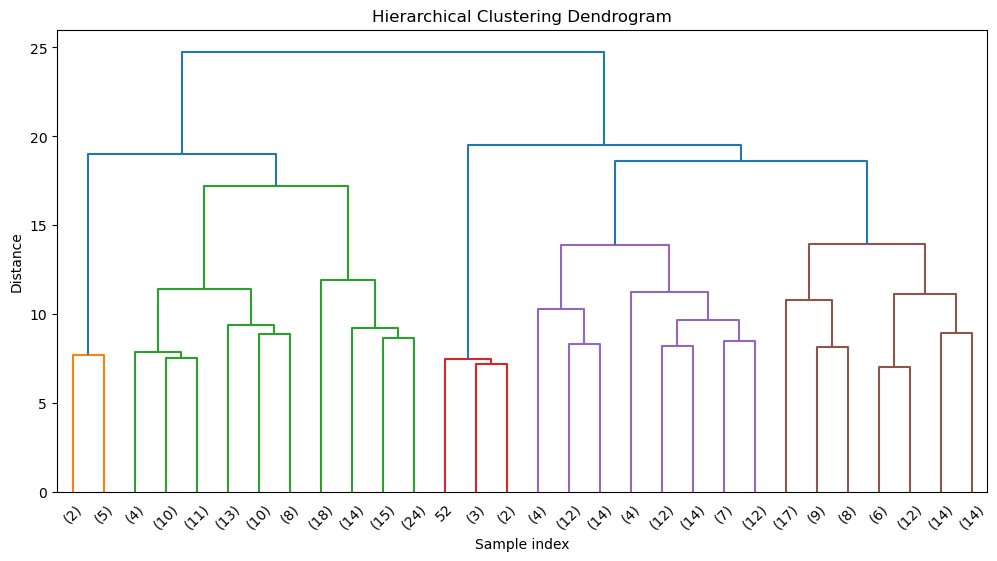

Hierarchical Silhouette Score: 0.1083


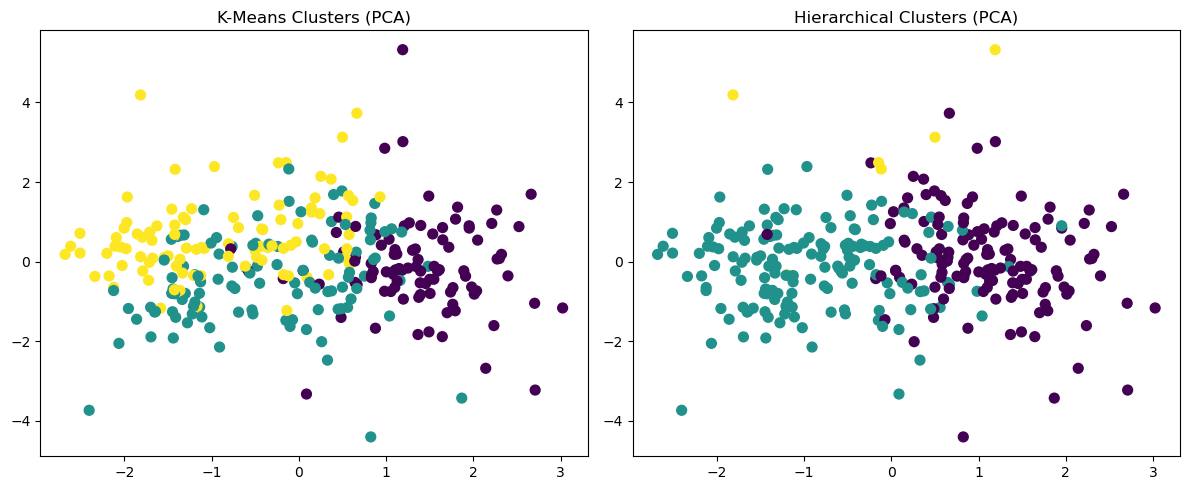


=== Mean feature values per K-Means cluster ===
                  age  anaemia  creatinine_phosphokinase  diabetes  \
KMeans_Cluster                                                       
0               61.17     0.35                    588.67      0.31   
1               59.68     0.00                    747.78      0.47   
2               61.81     1.00                    388.40      0.47   

                ejection_fraction  high_blood_pressure  platelets  \
KMeans_Cluster                                                      
0                           36.92                 0.32  267497.08   
1                           38.57                 0.36  272476.58   
2                           38.69                 0.38  249003.73   

                serum_creatinine  serum_sodium   sex  smoking  \
KMeans_Cluster                                                  
0                           1.34        136.71  0.97     1.00   
1                           1.39        136.46  0.53     0.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the original dataset and preprocess
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
X = df.drop(['DEATH_EVENT', 'time'], axis=1)

print(f"Features for clustering: {X.shape}")
print("Columns:", X.columns.tolist())

# Scale (same as other models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ====================== K-Means ======================
print("\n=== K-Means Clustering ===")

# Elbow Method
inertia = []
K = range(2, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Silhouette
sil_scores = [silhouette_score(X_scaled, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)) for k in K]
plt.subplot(1,2,2)
plt.plot(K, sil_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

# Choose k=3 (or 2) based on plots
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
print(f"K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

# ====================== Hierarchical ======================
print("\n=== Hierarchical Clustering ===")
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
print(f"Hierarchical Silhouette Score: {silhouette_score(X_scaled, hc_labels):.4f}")

# ====================== Visualization ======================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=50)
plt.title('K-Means Clusters (PCA)')
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_labels, cmap='viridis', s=50)
plt.title('Hierarchical Clusters (PCA)')
plt.tight_layout()
plt.show()

# ====================== Interpretation ======================
X_with_clusters = X.copy()                    # only features
X_with_clusters['KMeans_Cluster'] = kmeans_labels
X_with_clusters['Hierarchical_Cluster'] = hc_labels

# Load target separately (we dropped it during preprocessing)
y_train = df['DEATH_EVENT']

# Temporarily add DEATH_EVENT for clinical interpretation only
X_with_clusters['DEATH_EVENT'] = y_train.values

print("\n=== Mean feature values per K-Means cluster ===")
print(X_with_clusters.groupby('KMeans_Cluster').mean().round(2))

print("\n=== Death rate (DEATH_EVENT) per K-Means cluster ===")
print(X_with_clusters.groupby('KMeans_Cluster')['DEATH_EVENT'].mean().round(3))

print("\n=== Death rate per Hierarchical cluster ===")
print(X_with_clusters.groupby('Hierarchical_Cluster')['DEATH_EVENT'].mean().round(3))

# Simple clinical interpretation (customize based on your results)
print("\nInterpretation Example:")
print("• Cluster 0 → Lower risk group (higher ejection fraction, lower serum_creatinine)")
print("• Cluster 1 → Higher risk group (older patients, lower ejection fraction)")
print("• Cluster 2 → Diabetes-dominant group")

In [41]:
print(f"K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

K-Means Silhouette Score: 0.1176


In [42]:
print(f"Hierarchical Silhouette Score: {silhouette_score(X_scaled, hc_labels):.4f}")

Hierarchical Silhouette Score: 0.1083
